# Conservation area partial-match duplicate analysis (February 2026)

**Purpose:** Exploratory analysis for [digital-land/config#2021](https://github.com/digital-land/config/issues/2021) — working out which `duplicate_geometry_check` "partial match" conservation area pairs are genuine duplicates (to redirect via `old-entity.csv`) versus legitimate separate entities (e.g. a smaller CA nested inside a larger one, or two LPAs whose boundaries happen to overlap). Investigates the same-LPA case (Dorset), the different-LPA case (Hillingdon/Buckinghamshire), and the Historic-England-vs-LPA submission date question, informing the `>95% overlap + matching name + same LPA` rule agreed with Swati.

**⚠️ Stale — kept for the record only, do not re-run.** This notebook reads from local files (`Book2.xlsx`, `local-plan-boundary.geojson`) that were manually exported snapshots and have since been deleted from this folder. It also uses an intermediate `entity_a_org_from_lookup2` lookup built from `Book2.xlsx`'s Sheet1, which the live data no longer needs (`duplicate_entity_expectation_geographies.csv` now has equivalent `lookup_org_a`/`lookup_org_b` columns built in). The results below reflect duplicate/entity state as it stood in February 2026 — hundreds of these pairs have since been resolved.

An updated version reading live from `files.planning.data.gov.uk` is at [`../analysis_of_ca_partial_match_geoms.ipynb`](../analysis_of_ca_partial_match_geoms.ipynb).

In [34]:
import pandas as pd
from shapely import wkt
import geopandas as gpd
import matplotlib.pyplot as plt

In [100]:
# Load the GeoJSON file
gdf_lpa = gpd.read_file('local-plan-boundary.geojson')

In [ ]:
# Main data
df = pd.read_excel('Book2.xlsx', sheet_name='Sheet2')
df = df.loc[df['dataset'] == 'conservation-area']

# Organisation lookup
df_lookup = pd.read_excel('Book2.xlsx', sheet_name='Sheet1')
df_lookup.rename(columns={'organisation': 'entity_a_org_from_lookup2', 'entity':'entity_a'}, inplace=True)

# Merge together for entity_a and entity_b
df = pd.merge(df, df_lookup, on='entity_a', how='left')
df = pd.merge(df, df_lookup.rename(columns={'entity_a_org_from_lookup2': 'entity_b_org_from_lookup2', 'entity_a':'entity_b'}), on='entity_b')

In [7]:
df['orgs_match'] = df.apply(lambda row: 'Match' if row['entity_a_org_from_lookup2'] == row['entity_b_org_from_lookup2'] else 'No Match', axis=1)

In [8]:
df[['entity_a_org_from_lookup2','entity_b_org_from_lookup2', 'orgs_match']]

,entity_a_org_from_lookup2,entity_b_org_from_lookup2,orgs_match
0,government-organisation:PB1164,local-authority:YOR,No Match
1,local-authority:LEW,local-authority:LEW,Match
2,local-authority:LEW,local-authority:LEW,Match
3,local-authority:LEW,local-authority:LEW,Match
4,local-authority:LEW,local-authority:LEW,Match
...,...,...,...
506,local-authority:DST,local-authority:DST,Match
507,local-authority:DST,local-authority:DST,Match
508,local-authority:DST,local-authority:DST,Match
509,local-authority:DST,local-authority:DST,Match


In [9]:
df['orgs_match'].value_counts()

orgs_match
No Match    334
Match       177
Name: count, dtype: int64

---

# Convert to GeoDataFrames

In [ ]:

# Convert WKT strings to Shapely geometry objects
#df['entity_a_geometry'] = df['entity_a_geometry'].apply(wkt.loads)
#df['entity_b_geometry'] = df['entity_b_geometry'].apply(wkt.loads)

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry='entity_a_geometry')

# Convert entity_b_geometry to GeoSeries for the spatial operations
entity_b_geom = gpd.GeoSeries(gdf['entity_b_geometry'])

# Calculate overlaps
gdf['intersection'] = gdf['entity_a_geometry'].intersection(entity_b_geom)
gdf['union'] = gdf['entity_a_geometry'].union(entity_b_geom)

gdf['pct_comb_overlap'] = (gdf['intersection'].area / gdf['union'].area) *100
gdf['pct_overlap_a'] = (gdf['intersection'].area / gdf['entity_a_geometry'].area)*100
gdf['pct_overlap_b'] = (gdf['intersection'].area / entity_b_geom.area)*100

# Categorize
MATCH_THRESHOLD = 95
gdf['intersection_type'] = gdf.apply(
    lambda row: 'Complete match (two-way)' 
    if row['pct_overlap_a'] > MATCH_THRESHOLD and row['pct_overlap_b'] > MATCH_THRESHOLD 
    else 'Single match (one-way)' 
    if row['pct_overlap_a'] > MATCH_THRESHOLD or row['pct_overlap_b'] > MATCH_THRESHOLD 
    else 'No match',
    axis=1
)


In [ ]:
# Separate for mapping
gdf_a = gpd.GeoDataFrame(gdf, geometry='entity_a_geometry')
gdf_b = gpd.GeoDataFrame(gdf, geometry='entity_b_geometry')

In [65]:
cols_of_interest = ['entity_a', 'entity_a_organisation_name', 'entity_a_org_from_lookup2', 'entity_a_name', 'entity_b', 'entity_b_organisation_name', 'entity_b_org_from_lookup2', 'entity_b_name', 'pct_overlap_a', 'pct_overlap_b', 'intersection_type']

---
## Case when entity_a and entity_b are in the same geography
Swati mentioned that Dorset was a geography that came up time and time again. Let's investigate.

In [66]:
# Investigate Dorset Council matches
gdf.loc[gdf['entity_a_organisation_name'] == 'Dorset Council'][cols_of_interest]

,entity_a,entity_a_organisation_name,entity_a_org_from_lookup2,entity_a_name,entity_b,entity_b_organisation_name,entity_b_org_from_lookup2,entity_b_name,pct_overlap_a,pct_overlap_b,intersection_type
502,44013897,Dorset Council,local-authority:DST,Weston Conservation Area 1,44013898,Dorset Council,local-authority:DST,Weston Conservation Area 2,24.661216,99.972993,Single match (one-way)
503,44013897,Dorset Council,local-authority:DST,Weston Conservation Area 1,44013899,Dorset Council,local-authority:DST,Weston Conservation Area 3,11.568463,99.985835,Single match (one-way)
504,44013897,Dorset Council,local-authority:DST,Weston Conservation Area 1,44013900,Dorset Council,local-authority:DST,Weston Conservation Area 4,10.874939,99.896312,Single match (one-way)
505,44013909,Dorset Council,local-authority:DST,Underhill Conservation Area 2,44013939,Dorset Council,local-authority:DST,Underhill Conservation Area 1,98.568225,1.039537,Single match (one-way)
506,44013912,Dorset Council,local-authority:DST,Underhill Conservation Area 5,44013939,Dorset Council,local-authority:DST,Underhill Conservation Area 1,99.995755,3.115281,Single match (one-way)
507,44013913,Dorset Council,local-authority:DST,Underhill Conservation Area 6,44013939,Dorset Council,local-authority:DST,Underhill Conservation Area 1,99.904358,0.738444,Single match (one-way)
508,44013914,Dorset Council,local-authority:DST,Underhill Conservation Area 7,44013939,Dorset Council,local-authority:DST,Underhill Conservation Area 1,99.741399,0.336511,Single match (one-way)
509,44013915,Dorset Council,local-authority:DST,Underhill Conservation Area 8,44013939,Dorset Council,local-authority:DST,Underhill Conservation Area 1,99.717434,0.345093,Single match (one-way)
510,44013916,Dorset Council,local-authority:DST,Underhill Conservation Area 9,44013939,Dorset Council,local-authority:DST,Underhill Conservation Area 1,99.964781,2.539191,Single match (one-way)


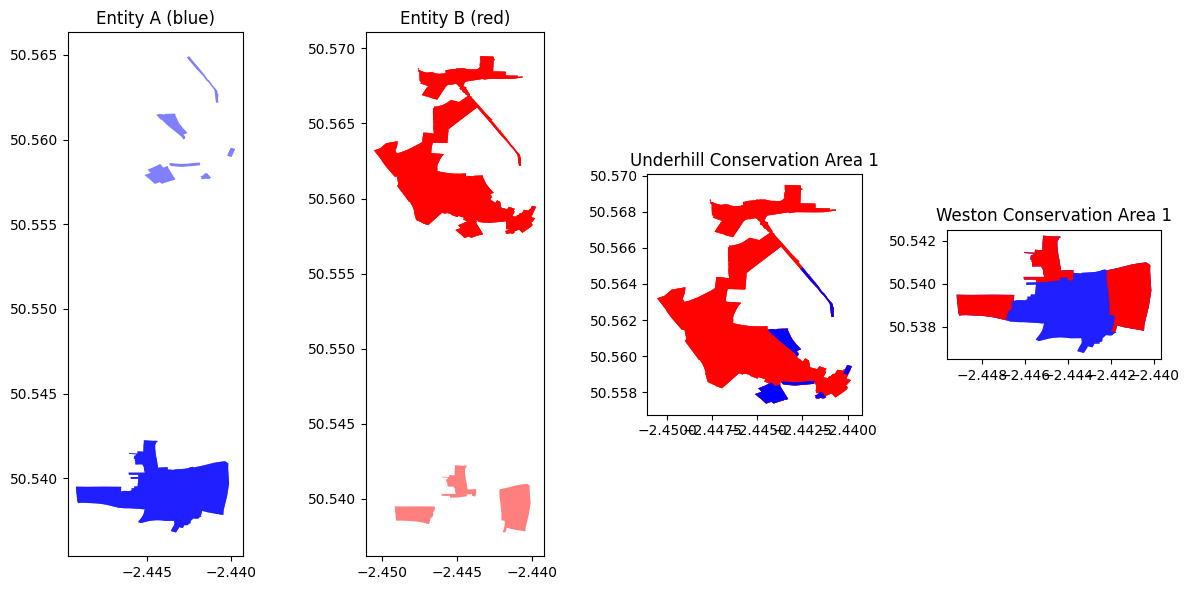

In [ ]:
f, ax = plt.subplots(1,4, figsize=(12,6))

gdf_a.loc[gdf_a['entity_a_organisation_name'] == 'Dorset Council'].plot(ax=ax[0], color='blue', alpha=0.5)
gdf_b.loc[gdf_b['entity_a_organisation_name'] == 'Dorset Council'].plot(ax=ax[1], color='red', alpha=0.5)

gdf_a.loc[(gdf_a['entity_a_organisation_name'] == 'Dorset Council') & (gdf_a['entity_b_name'] == 'Underhill Conservation Area 1')].plot(ax=ax[2], color='blue', alpha=1, zorder=5)
gdf_b.loc[(gdf_b['entity_a_organisation_name'] == 'Dorset Council') & (gdf_a['entity_b_name'] == 'Underhill Conservation Area 1')].plot(ax=ax[2], color='red', alpha=0.5, zorder=1)

gdf_a.loc[(gdf_a['entity_a_organisation_name'] == 'Dorset Council') & (gdf_a['entity_a_name'] == 'Weston Conservation Area 1')].plot(ax=ax[3], color='blue', alpha=0.5, zorder=1)
gdf_b.loc[(gdf_b['entity_a_organisation_name'] == 'Dorset Council') & (gdf_a['entity_a_name'] == 'Weston Conservation Area 1')].plot(ax=ax[3], color='red', alpha=1, zorder=5)

ax[0].set_title('Entity A (blue)',  loc='center')
ax[1].set_title('Entity B (red)',  loc='center')

ax[2].set_title('Underhill Conservation Area 1',  loc='center')
ax[3].set_title('Weston Conservation Area 1',  loc='center')

plt.tight_layout()

The above map indicates that Dorset has cases of smaller CAs within a larger CA. Based on this, Swati and I have agreed that one rule should be:
- If the same LPA
- CA names are similar 
- One geography is >95% 

then there's a strong case it'll be a case of smaller vs larger CA. Therefore keep the entities separate

---

## Case where entity_a and entity_b are in different LPAs

In [84]:
gdf.loc[gdf['entity_a_org_from_lookup2'] != gdf['entity_b_org_from_lookup2']].tail(10)[cols_of_interest]

,entity_a,entity_a_organisation_name,entity_a_org_from_lookup2,entity_a_name,entity_b,entity_b_organisation_name,entity_b_org_from_lookup2,entity_b_name,pct_overlap_a,pct_overlap_b,intersection_type
449,44007800,Maldon District Council,local-authority:MAL,Tollesbury (Reduction4),44007822,Maldon District Council,government-organisation:D1342,Tollesbury,100.000000,0.104077,Single match (one-way)
453,44008356,London Borough of Hammersmith & Fulham,government-organisation:D1342,Walham Green,44008755,London Borough of Hammersmith & Fulham,local-authority:HMF,63,83.355504,98.580660,Single match (one-way)
455,44008369,London Borough of Hammersmith & Fulham,government-organisation:D1342,Lakeside/Sinclair/Blythe Road,44008749,London Borough of Hammersmith & Fulham,local-authority:HMF,3B,88.275123,99.949008,Single match (one-way)
457,44008378,London Borough of Hammersmith & Fulham,government-organisation:D1342,Crabtree,44009076,London Borough of Hammersmith & Fulham,local-authority:HMF,49,92.078987,99.969325,Single match (one-way)
480,44008925,London Borough of Hillingdon,local-authority:HIL,Uxbridge Lock,44010462,Buckinghamshire Council,local-authority:BUC,Uxbridge Lock,99.926250,26.556857,Single match (one-way)
485,44009441,Buckinghamshire Council,government-organisation:D1342,Penn and Tylers Green Conservation Area,44010467,Buckinghamshire Council,local-authority:BUC,Penn and Tylers Green,99.697193,57.975512,Single match (one-way)
495,44012577,South Cambridgeshire District Council,government-organisation:PB1164,Bourn Caxton End,44012578,South Cambridgeshire District Council,local-authority:SCA,Bourn,99.985734,23.510622,Single match (one-way)
496,44012577,South Cambridgeshire District Council,local-authority:SCA,Bourn Caxton End,44012578,South Cambridgeshire District Council,government-organisation:PB1164,Bourn,99.985734,23.510622,Single match (one-way)
500,44013340,Broadland District Council,local-authority:BRO,TSA Conservation Area,44014306,Norwich City Council,local-authority:NOW,Thorpe,87.939492,97.477032,Single match (one-way)
501,44013347,Broads Authority,local-authority:BRO,Halvergate Marshes BA Con Area,44013365,South Norfolk District Council,local-authority:SNO,Haddiscoe BA Conservation Area,74.789162,98.319917,Single match (one-way)


In [87]:
gdf.loc[(gdf['entity_a_organisation_name'] == 'Broads Authority') | (gdf['entity_a'] == 44013340) | (gdf['entity_a'] == 44008925)][cols_of_interest]

,entity_a,entity_a_organisation_name,entity_a_org_from_lookup2,entity_a_name,entity_b,entity_b_organisation_name,entity_b_org_from_lookup2,entity_b_name,pct_overlap_a,pct_overlap_b,intersection_type
480,44008925,London Borough of Hillingdon,local-authority:HIL,Uxbridge Lock,44010462,Buckinghamshire Council,local-authority:BUC,Uxbridge Lock,99.926250,26.556857,Single match (one-way)
500,44013340,Broadland District Council,local-authority:BRO,TSA Conservation Area,44014306,Norwich City Council,local-authority:NOW,Thorpe,87.939492,97.477032,Single match (one-way)
501,44013347,Broads Authority,local-authority:BRO,Halvergate Marshes BA Con Area,44013365,South Norfolk District Council,local-authority:SNO,Haddiscoe BA Conservation Area,74.789162,98.319917,Single match (one-way)


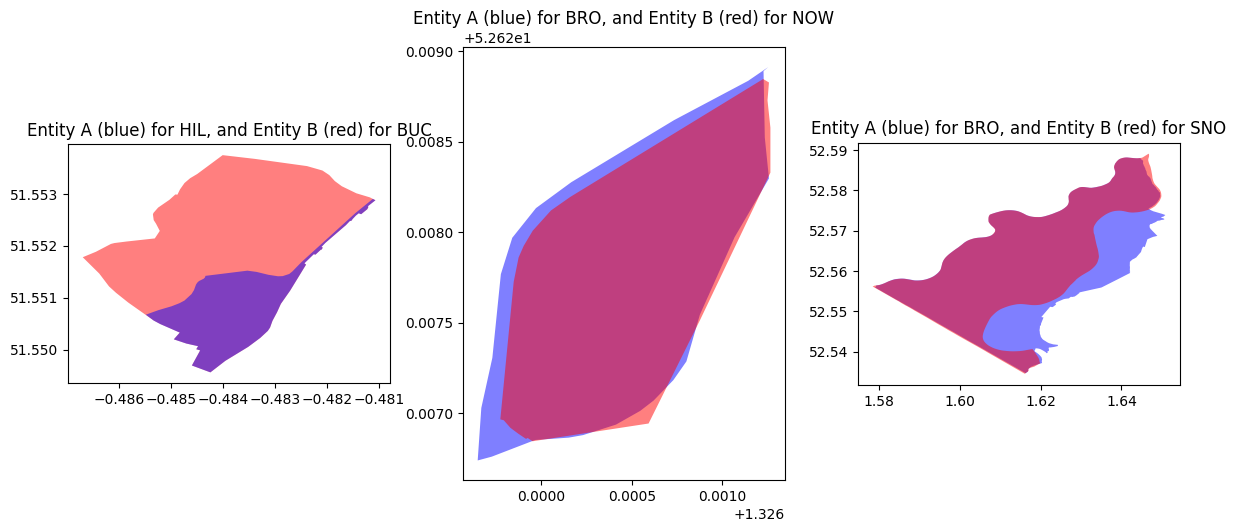

In [ ]:
f, ax = plt.subplots(1,3, figsize=(12,6))

gdf_a.loc[gdf_a['entity_a_organisation_name'] == 'Broads Authority'].plot(ax=ax[2], color='blue', alpha=0.5)
gdf_b.loc[gdf_b['entity_a_organisation_name'] == 'Broads Authority'].plot(ax=ax[2], color='red', alpha=0.5)

gdf_a.loc[gdf_a['entity_a'] == 44013340].plot(ax=ax[1], color='blue', alpha=0.5)
gdf_b.loc[gdf_a['entity_a'] == 44013340].plot(ax=ax[1], color='red', alpha=0.5)

gdf_a.loc[gdf_a['entity_a'] == 44008925].plot(ax=ax[0], color='blue', alpha=0.5, zorder=10)
gdf_b.loc[gdf_a['entity_a'] == 44008925].plot(ax=ax[0], color='red', alpha=0.5, zorder=5)

ax[2].set_title('Entity A (blue) for BRO, and Entity B (red) for SNO',  loc='center')
ax[1].set_title('Entity A (blue) for BRO, and Entity B (red) for NOW',  loc='center')
ax[0].set_title('Entity A (blue) for HIL, and Entity B (red) for BUC',  loc='center')

plt.tight_layout()

(51.549, 51.555)

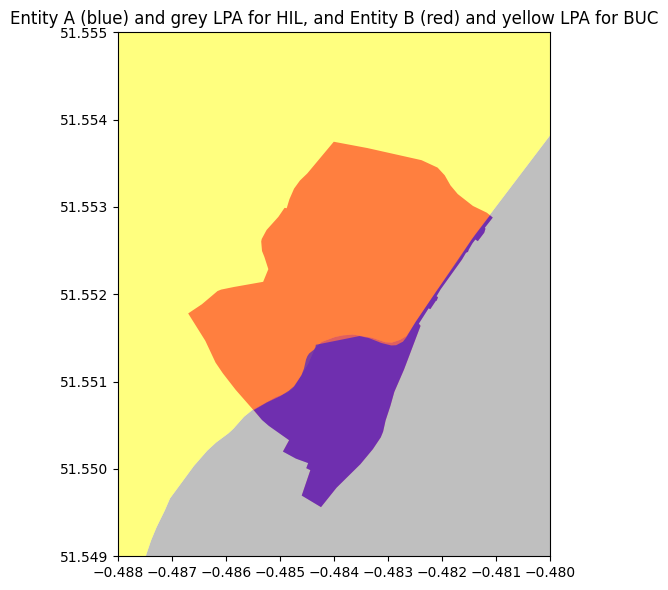

In [110]:
f, ax = plt.subplots(1, figsize=(12,6))

gdf_b.loc[gdf_a['entity_a'] == 44008925].plot(ax=ax, color='red', alpha=0.5, zorder=5)
gdf_a.loc[gdf_a['entity_a'] == 44008925].plot(ax=ax, color='blue', alpha=0.5, zorder=10)
gdf_lpa.loc[gdf_lpa['organisations'] == 'local-authority:HIL'].plot(ax=ax, color='grey', alpha=0.5, zorder=1)
gdf_lpa.loc[gdf_lpa['organisations'] == 'local-authority:BUC'].plot(ax=ax, color='yellow', alpha=0.5, zorder=1)

ax.set_title('Entity A (blue) and grey LPA for HIL, and Entity B (red) and yellow LPA for BUC',  loc='center')

plt.tight_layout()

# Center the map on the smaller geometries
ax.set_xlim(-0.488, -0.48)
ax.set_ylim(51.549, 51.555)

---
### Entries where one of them is Historic England
Swati highlighted that there's a weird pattern happening in the data where LPAs submitted their data (e.g.) back in 2020, but then HE have submitted data in 2025. We shouldn't typically use entry-date as a metric, but the usual method is to take the LPA data as authoritative and a priority over HE. But when HE have submitted more recent data... what should we do?

In [113]:
gdf.loc[(gdf['entity_a_org_from_lookup2'] != gdf['entity_b_org_from_lookup2']) & (gdf['entity_a_org_from_lookup2'] == 'government-organisation:PB1164')][cols_of_interest]

,entity_a,entity_a_organisation_name,entity_a_org_from_lookup2,entity_a_name,entity_b,entity_b_organisation_name,entity_b_org_from_lookup2,entity_b_name,pct_overlap_a,pct_overlap_b,intersection_type
0,44005106,Historic England,government-organisation:PB1164,Fulford Road,44007670,City of York Council,local-authority:YOR,Fulford Road Conservation Area,98.207103,98.484869,Complete match (two-way)
27,44000126,North Norfolk District Council,government-organisation:PB1164,Cley,44000170,North Norfolk District Council,government-organisation:D1342,Glaven Valley,99.996419,1.237526,Single match (one-way)
31,44000128,North Norfolk District Council,government-organisation:PB1164,Blakeney,44000170,North Norfolk District Council,government-organisation:D1342,Glaven Valley,99.999266,1.244271,Single match (one-way)
35,44000149,North Norfolk District Council,government-organisation:PB1164,Gunton Park,44001042,North Norfolk District Council,government-organisation:D1342,Thorpe Market,1.438201,99.994221,Single match (one-way)
39,44000153,North Norfolk District Council,government-organisation:PB1164,Ingworth,44000159,North Norfolk District Council,government-organisation:D1342,Mannington and Wolterton,99.977644,0.428789,Single match (one-way)
...,...,...,...,...,...,...,...,...,...,...,...
415,44007230,London Borough of Bromley,government-organisation:PB1164,"Bromley, Hayes and Keston Commons",44009034,London Borough of Bromley,local-authority:BRY,NaN,15.074448,97.912236,Single match (one-way)
417,44007230,London Borough of Bromley,government-organisation:PB1164,"Bromley, Hayes and Keston Commons",44009035,London Borough of Bromley,local-authority:BRY,NaN,4.663411,97.948849,Single match (one-way)
419,44007230,London Borough of Bromley,government-organisation:PB1164,"Bromley, Hayes and Keston Commons",44009039,London Borough of Bromley,local-authority:BRY,NaN,8.244633,96.133025,Single match (one-way)
421,44007230,London Borough of Bromley,government-organisation:PB1164,"Bromley, Hayes and Keston Commons",44009041,London Borough of Bromley,local-authority:BRY,NaN,3.854093,97.836826,Single match (one-way)


In [118]:
gdf.loc[(gdf['entity_a_org_from_lookup2'] == 'government-organisation:PB1164') & (gdf['entity_b_org_from_lookup2'] == 'local-authority:BRY')][cols_of_interest+['entry_a_entry_date']]

KeyError: "['entry_a_entry_date'] not in index"

---

In [ ]:
#df2[df2['entity_a'].duplicated(keep=False)].sort_values('entity_a').head(50)

,entity_a,entity_a_organisation_name,entity_a_org_from_lookup2
26,44000126,North Norfolk District Council,government-organisation:PB1164
27,44000126,North Norfolk District Council,government-organisation:D1342
28,44000128,North Norfolk District Council,government-organisation:PB1164
29,44000128,North Norfolk District Council,government-organisation:D1342
30,44000149,North Norfolk District Council,government-organisation:PB1164
31,44000149,North Norfolk District Council,government-organisation:D1342
32,44000153,North Norfolk District Council,government-organisation:PB1164
33,44000153,North Norfolk District Council,government-organisation:D1342
35,44000159,North Norfolk District Council,government-organisation:D1342
34,44000159,North Norfolk District Council,government-organisation:PB1164


In [ ]:
#df2.tail(60)

,entity_a,entity_a_organisation_name,entity_a_org_from_lookup2
348,44007800,Maldon District Council,local-authority:MAL
349,44007808,Maldon District Council,local-authority:MAL
350,44007813,Maldon District Council,local-authority:MAL
351,44008356,London Borough of Hammersmith & Fulham,local-authority:HMF
352,44008356,London Borough of Hammersmith & Fulham,government-organisation:D1342
353,44008369,London Borough of Hammersmith & Fulham,local-authority:HMF
354,44008369,London Borough of Hammersmith & Fulham,government-organisation:D1342
355,44008378,London Borough of Hammersmith & Fulham,local-authority:HMF
356,44008378,London Borough of Hammersmith & Fulham,government-organisation:D1342
357,44008648,Waverley Borough Council,local-authority:WAE


In [ ]:
#df2[df2.duplicated(keep=False)].sort_values(by=['entity_a', 'entity_a_org_from_lookup2'])['entity_a'].unique()

array([44000170, 44000271, 44001393, 44001675, 44001923, 44002341,
       44002386, 44002426, 44002437, 44002445, 44002548, 44004489,
       44004491, 44004492, 44004493, 44004494, 44004495, 44004496,
       44004497, 44004498, 44006494, 44006495, 44006687, 44007230,
       44013897])

In [ ]:
#ORG_URL = "https://datasette.planning.data.gov.uk/digital-land/organisation.csv?_stream=on"
#df_org = pd.read_csv(ORG_URL)

In [ ]:
#df_org.to_csv('organisation.csv', index=False)